# 2_08 — Which subsites should the score use?

## Scope

Every score computed so far sums all eight subsites, $P_4 \ldots P_4'$, whenever
the peptide occupies them. That is a choice and not a necessity, and there are
specific reasons to doubt it.

* The **prime side is the leaving group**. For a quenched reporter substrate the
  experimenter designs the non-prime side around the known preference and the
  prime side around the quencher chemistry, so prime-side residues carry design
  rather than specificity.
* **qPISA cannot see $P_4$ and $P_3$ at all** (`0_06`), and MEROPS matrices for
  several panel proteases rest on counts thin enough that the outer subsites are
  mostly prior (`0_01`).
* `1_01` shows the score is a **sum of mostly negative terms**, so every subsite
  added drags the total down and a longer window is not automatically a more
  informative one.

If the outer or the prime subsites are noise, dropping them should **improve** the
relation between the score and the measured rate, not merely simplify it. That is
a testable claim and this notebook tests it, on both analysis datasets.

## The variants

| Variant | Subsites | Rationale |
| --- | --- | --- |
| `full` | $P_4 \ldots P_4'$ | the current model |
| `non_prime` | $P_4 \ldots P_1$ | the side the enzyme recognises before catalysis |
| `prime` | $P_1' \ldots P_4'$ | the leaving group alone |
| `core` | $P_2 \ldots P_2'$ | the four subsites nearest the scissile bond |
| `P1_P1p` | $P_1, P_1'$ | the bond itself |
| `P3_P1` | $P_3 \ldots P_1$ | non-prime, outermost subsite dropped |
| `P2_P1` | $P_2, P_1$ | non-prime, two outermost dropped |
| `P1_only` | $P_1$ | the single residue classical specificity is stated in |

## How a restricted score is computed

Restricting a window is done by marking the excluded subsites absent, not by
shortening the array, so the subsite axis stays aligned with the matrix and the
same scoring function applies. For a substrate whose bond is latent the maximum is
re-taken **under the restricted window**, because that is what the model would
actually do; the variant that keeps the full-window bond fixed is carried
alongside as a control, to separate a change in the score from a change in which
bond is nominated.

## Execution contract

**Inputs:** `results/0_15_dataset_baseline.csv`; `results/0_15_dataset_extended.csv`; `data/merops/34_homo_sapiens/matrices_logprob.npy`; `data/reference/human_proteome/composition.json`.

**Outputs:** `results/2_08_window_variants.csv`; `results/2_08_variant_per_protease.csv`; `results/2_08_variant_paired.csv`; `results/2_08_variant_bond_separation.csv`.

**Depends on:** `0_15`.

**Boundary:** Selecting a window variant on these data does not provide an independent held-out calibration.

In [1]:
import sys
from pathlib import Path

# The shared module sits one directory above the notebook; locating it by content
# keeps the notebooks working if the analysis directory is renamed or renumbered.
_cwd = Path.cwd().resolve()
_notebooks = next(p for p in [_cwd, *_cwd.parents] if (p / "_analysis_common.py").is_file())
sys.path.insert(0, str(_notebooks))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import spearmanr

import _analysis_common as common
from pep_compass.optimization.components.helpers.proteolysis import (
    MEROPS_SUBSITES,
    EventGeometry,
    allowed_cut_positions,
    load_amino_acid_background,
    load_panel_metadata,
    load_protease_panel,
    masked_score_from_indices,
    parse_substrate,
    reporter_window_indices,
    restrict_window_indices,
    window_residue_indices,
)

common.apply_style()

## Parameters

Every knob this notebook has is in the cell below: thresholds, filters, sample
sizes and seeds. Shared policy that several notebooks obey — the assay-condition
window, the minimum evidence per protease, the permutation count — lives in
`_analysis_common.py` and is imported rather than repeated, so a change there
reaches every notebook that does not override it here.

In [2]:
VARIANTS = {
    "full": ("P4", "P3", "P2", "P1", "P1p", "P2p", "P3p", "P4p"),
    "non_prime": ("P4", "P3", "P2", "P1"),
    "prime": ("P1p", "P2p", "P3p", "P4p"),
    "core": ("P2", "P1", "P1p", "P2p"),
    "P1_P1p": ("P1", "P1p"),
    "P3_P1": ("P3", "P2", "P1"),
    "P2_P1": ("P2", "P1"),
    "P1_only": ("P1",),
}
DATASETS = ("baseline", "extended")
HUMAN_MEROPS_DATASETS = (34, 35)
MIN_ROWS_PER_PROTEASE = common.MIN_ROWS_FOR_CORRELATION
N_PERMUTATIONS = common.N_PERMUTATIONS
SEED = common.SEED

In [3]:
rng = np.random.default_rng(SEED)
human_background = load_amino_acid_background(
    common.ROOT / "data" / "reference" / "human_proteome" / "composition.json"
)

## One human matrix per code, from whichever human dataset holds the most evidence
matrices: dict[str, np.ndarray] = {}
best_counts: dict[str, int] = {}
for dataset_id in HUMAN_MEROPS_DATASETS:
    panel = load_protease_panel(dataset_id, merops_root=common.MEROPS_ROOT, kind="logprob", device="cpu")
    counts = {
        entry["code"]: entry["n_cleavages"]
        for entry in load_panel_metadata(dataset_id, merops_root=common.MEROPS_ROOT)
    }
    stack = panel.matrices.numpy().astype(np.float64)
    for position, code in enumerate(panel.codes):
        n = int(counts.get(code, 0))
        if code not in matrices or n > best_counts[code]:
            matrices[code] = stack[position]
            best_counts[code] = n

datasets = {name: pd.read_csv(common.RESULTS_ROOT / f"0_15_dataset_{name}.csv") for name in DATASETS}
for name, frame in datasets.items():
    print(f"{name}: {len(frame)} rows, {frame['merops_code'].nunique()} proteases, "
          f"{int((frame['window_convention'] == 'reporter').sum())} reporter rows")

baseline: 330 rows, 17 proteases, 150 reporter rows
extended: 746 rows, 58 proteases, 475 reporter rows


## Rescoring every row under every variant

In [4]:
def score_row(row: pd.Series, subsites: tuple[str, ...], refit_bond: bool) -> tuple[float, int, float]:
    """Score one substrate under a restricted window.

    :param row: A row of an analysis dataset.
    :param subsites: Subsites the variant keeps.
    :param refit_bond: Whether to re-take the maximum over bonds under the
        restricted window, as the model would, rather than keeping the bond the
        full window chose.
    :return: Tuple of the score, the subsites it summed, and the bond used.
    """

    matrix = matrices[row["merops_code"]]
    sequence = row["substrate_sequence"]

    if row["window_convention"] == "reporter":
        indices = reporter_window_indices(parse_substrate(row["substrate_raw"]))
        score, observed = masked_score_from_indices(
            sequence, restrict_window_indices(indices, subsites), matrix, background=human_background
        )
        return score, observed, float("nan")

    geometry = EventGeometry(row["event_geometry"])
    admissible = np.flatnonzero(allowed_cut_positions(len(sequence), geometry))
    if len(admissible) == 0:
        return float("nan"), 0, float("nan")

    if not refit_bond and np.isfinite(row["implied_bond"]):
        candidates = [int(row["implied_bond"])]
    else:
        candidates = [int(bond) for bond in admissible]

    best_score, best_observed, best_bond = -np.inf, 0, np.nan
    for bond in candidates:
        indices = restrict_window_indices(window_residue_indices(len(sequence), bond), subsites)
        score, observed = masked_score_from_indices(sequence, indices, matrix, background=human_background)
        if observed > 0 and score > best_score:
            best_score, best_observed, best_bond = score, observed, float(bond)
    if not np.isfinite(best_score):
        return float("nan"), 0, float("nan")
    return best_score, best_observed, best_bond


scored_rows = []
for dataset_name, frame in datasets.items():
    usable = frame[frame["merops_code"].isin(matrices)]
    for variant, subsites in VARIANTS.items():
        for refit_bond in (True, False):
            values = [score_row(row, subsites, refit_bond) for _, row in usable.iterrows()]
            scored_rows.append(
                pd.DataFrame(
                    {
                        "dataset": dataset_name,
                        "variant": variant,
                        "bond_refitted": refit_bond,
                        "merops_code": usable["merops_code"].to_numpy(),
                        "substrate_raw": usable["substrate_raw"].to_numpy(),
                        "window_convention": usable["window_convention"].to_numpy(),
                        "log10_kcat_over_km": usable["log10_kcat_over_km"].to_numpy(),
                        "score": [value[0] for value in values],
                        "observed_subsites": [value[1] for value in values],
                        "bond": [value[2] for value in values],
                    }
                )
            )

variant_scores = pd.concat(scored_rows, ignore_index=True).dropna(subset=["score"])
print(f"scored rows: {len(variant_scores):,}")
print(variant_scores.groupby(["dataset", "bond_refitted"]).size().to_string())

scored rows: 17,216
dataset   bond_refitted
baseline  False            2640
          True             2640
extended  False            5968
          True             5968


## Does a shorter window predict the rate better?

The statistic is the one every notebook in this series uses: the Spearman
correlation between the score and the measured efficiency, computed **within** a
protease and pooled with weights proportional to the number of substrates. A
variant that removes noise will raise it; one that removes signal will lower it.

In [5]:
def pooled_correlation(frame: pd.DataFrame) -> tuple[float, int, int]:
    """Return the sample-weighted pooled within-protease rank correlation.

    :param frame: Scored rows for one dataset and variant.
    :return: Tuple of pooled rho, protease count and row count.
    """

    usable = frame.groupby("merops_code").filter(lambda group: len(group) >= MIN_ROWS_PER_PROTEASE)
    values, weights = [], []
    for _, group in usable.groupby("merops_code"):
        correlation = spearmanr(group["score"], group["log10_kcat_over_km"]).statistic
        if np.isfinite(correlation):
            values.append(correlation)
            weights.append(len(group))
    if not values:
        return float("nan"), 0, len(usable)
    return float(np.average(values, weights=weights)), len(values), len(usable)


summary_rows = []
for (dataset_name, variant, refit_bond), group in variant_scores.groupby(["dataset", "variant", "bond_refitted"]):
    rho, n_proteases, n_rows = pooled_correlation(group)
    summary_rows.append(
        {
            "dataset": dataset_name,
            "variant": variant,
            "bond_refitted": refit_bond,
            "subsites": len(VARIANTS[variant]),
            "pooled_rho": rho,
            "proteases": n_proteases,
            "rows": n_rows,
            "median_observed_subsites": float(group["observed_subsites"].median()),
        }
    )
summary = pd.DataFrame(summary_rows)

main = summary[summary["bond_refitted"]].copy()
for dataset_name in DATASETS:
    reference = main.loc[(main["dataset"] == dataset_name) & (main["variant"] == "full"), "pooled_rho"].iloc[0]
    main.loc[main["dataset"] == dataset_name, "change_vs_full"] = (
        main.loc[main["dataset"] == dataset_name, "pooled_rho"] - reference
    )

print(
    main.sort_values(["dataset", "pooled_rho"], ascending=[True, False])
    [["dataset", "variant", "subsites", "pooled_rho", "change_vs_full", "proteases", "rows"]]
    .round(4).to_string(index=False)
)

/tmp/ipykernel_961856/2185983642.py:11: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  correlation = spearmanr(group["score"], group["log10_kcat_over_km"]).statistic
/tmp/ipykernel_961856/2185983642.py:11: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  correlation = spearmanr(group["score"], group["log10_kcat_over_km"]).statistic
/tmp/ipykernel_961856/2185983642.py:11: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  correlation = spearmanr(group["score"], group["log10_kcat_over_km"]).statistic
/tmp/ipykernel_961856/2185983642.py:11: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  correlation = spearmanr(group["score"], group["log10_kcat_over_km"]).statistic


/tmp/ipykernel_961856/2185983642.py:11: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  correlation = spearmanr(group["score"], group["log10_kcat_over_km"]).statistic
/tmp/ipykernel_961856/2185983642.py:11: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  correlation = spearmanr(group["score"], group["log10_kcat_over_km"]).statistic
/tmp/ipykernel_961856/2185983642.py:11: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  correlation = spearmanr(group["score"], group["log10_kcat_over_km"]).statistic
/tmp/ipykernel_961856/2185983642.py:11: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  correlation = spearmanr(group["score"], group["log10_kcat_over_km"]).statistic
/tmp/ipykernel_961856/2185983642.py:11: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr

/tmp/ipykernel_961856/2185983642.py:11: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  correlation = spearmanr(group["score"], group["log10_kcat_over_km"]).statistic
/tmp/ipykernel_961856/2185983642.py:11: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  correlation = spearmanr(group["score"], group["log10_kcat_over_km"]).statistic


 dataset   variant  subsites  pooled_rho  change_vs_full  proteases  rows
baseline non_prime         4      0.3732          0.0687         16   327
baseline     P3_P1         3      0.3574          0.0529         16   327
baseline      full         8      0.3045          0.0000         16   327
baseline     P2_P1         2      0.2522         -0.0523         16   327
baseline      core         4      0.2421         -0.0624         16   327
baseline    P1_P1p         2      0.1991         -0.1054         11   327
baseline   P1_only         1      0.1919         -0.1126         10   327
baseline     prime         4      0.1534         -0.1511          8   327
extended      full         8      0.3728          0.0000         55   737
extended non_prime         4      0.3482         -0.0246         54   737
extended     P3_P1         3      0.3262         -0.0466         54   737
extended      core         4      0.3234         -0.0494         55   737
extended    P1_P1p         2      0.31

/tmp/ipykernel_961856/2185983642.py:11: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  correlation = spearmanr(group["score"], group["log10_kcat_over_km"]).statistic
/tmp/ipykernel_961856/2185983642.py:11: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  correlation = spearmanr(group["score"], group["log10_kcat_over_km"]).statistic
/tmp/ipykernel_961856/2185983642.py:11: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  correlation = spearmanr(group["score"], group["log10_kcat_over_km"]).statistic


### Reading the figure

Each panel is one dataset; each bar a window variant, ordered by how well it
predicts the rate. The dashed line is the current model, the full eight-subsite
window. A bar to the right of it is a variant that predicts better while using
less information, which would mean the subsites it drops were adding noise.

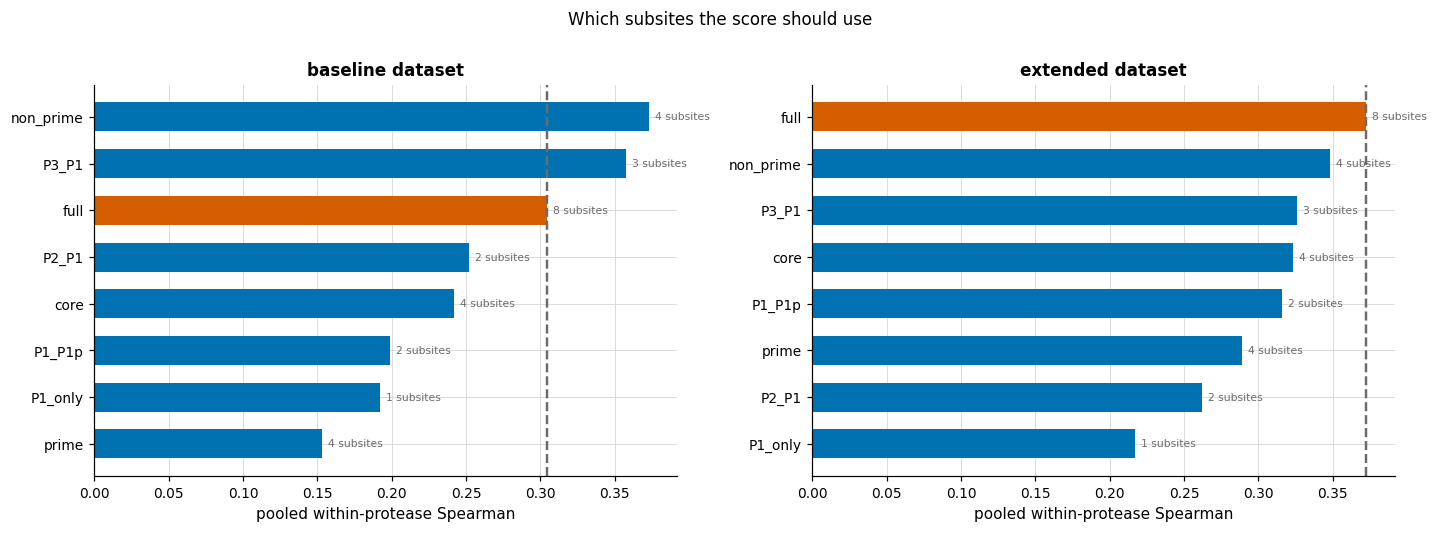

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13.2, 4.8), sharex=True)
for ax, dataset_name in zip(axes, DATASETS):
    subset = main[main["dataset"] == dataset_name].sort_values("pooled_rho")
    colours = [
        common.CATEGORICAL_COLORS[1] if name == "full" else common.CATEGORICAL_COLORS[0]
        for name in subset["variant"]
    ]
    ax.barh(subset["variant"], subset["pooled_rho"], color=colours, height=0.62)
    reference = subset.loc[subset["variant"] == "full", "pooled_rho"].iloc[0]
    ax.axvline(reference, color=common.NEUTRAL, linestyle="--", linewidth=1.6)
    for position, row in enumerate(subset.itertuples()):
        ax.text(row.pooled_rho + 0.004, position, f"{row.subsites} subsites",
                va="center", fontsize=7, color=common.NEUTRAL)
    ax.set_xlabel("pooled within-protease Spearman")
    ax.set_title(f"{dataset_name} dataset")
fig.suptitle("Which subsites the score should use", y=1.0, fontsize=11)
fig.tight_layout()
plt.show()

**Provenance**

`results/0_15_dataset_baseline.csv` and `0_15_dataset_extended.csv` are assembled from BRENDA 2026.1 and MEROPS 2023 in notebook `0_15`; code cells 4–8 rescore the same mapped substrate rows using subsite subsets from cell 3. One plotted statistic is pooled within-protease Spearman ρ for a dataset and variant, with counts of rows/proteases retained in `results/2_08_window_variants.csv`. The `bond_refitted` dimension distinguishes a fixed inferred bond from reselecting the maximum under each variant. Kinetic labels remain log10 kcat/Km in 1/(M·s); scores are dimensionless. Inspect `results/2_08_variant_per_protease.csv` and `2_08_variant_bond_separation.csv` before interpreting a change in pooled ρ. Variant choice and bond re-selection use the evaluation rows themselves, so any gain is exploratory.


## Per protease, and whether the effect is general

A pooled value can be produced by one protease with many substrates. The
per-protease table says whether a variant that wins on the pool wins on the
individual enzymes, and a sign test over proteases says whether the direction is
consistent rather than driven by the largest contributors.

In [7]:
per_protease_rows = []
for (dataset_name, variant), group in variant_scores[variant_scores["bond_refitted"]].groupby(["dataset", "variant"]):
    for code, rows in group.groupby("merops_code"):
        if len(rows) < MIN_ROWS_PER_PROTEASE:
            continue
        correlation = spearmanr(rows["score"], rows["log10_kcat_over_km"]).statistic
        if np.isfinite(correlation):
            per_protease_rows.append(
                {"dataset": dataset_name, "variant": variant, "merops_code": code,
                 "substrates": len(rows), "rho": float(correlation)}
            )
per_protease = pd.DataFrame(per_protease_rows)

comparison_rows = []
for dataset_name in DATASETS:
    reference = per_protease[(per_protease["dataset"] == dataset_name) & (per_protease["variant"] == "full")]
    reference = reference.set_index("merops_code")["rho"]
    for variant in VARIANTS:
        if variant == "full":
            continue
        candidate = per_protease[(per_protease["dataset"] == dataset_name) & (per_protease["variant"] == variant)]
        candidate = candidate.set_index("merops_code")["rho"]
        shared = reference.index.intersection(candidate.index)
        if len(shared) < 3:
            continue
        better = int((candidate[shared] > reference[shared]).sum())
        comparison_rows.append(
            {
                "dataset": dataset_name,
                "variant": variant,
                "shared_proteases": len(shared),
                "better_than_full": better,
                "share_better": better / len(shared),
                "mean_rho_full": float(reference[shared].mean()),
                "mean_rho_variant": float(candidate[shared].mean()),
            }
        )
paired = pd.DataFrame(comparison_rows)
print(paired.round(3).to_string(index=False))

/tmp/ipykernel_961856/3311820681.py:6: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  correlation = spearmanr(rows["score"], rows["log10_kcat_over_km"]).statistic
/tmp/ipykernel_961856/3311820681.py:6: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  correlation = spearmanr(rows["score"], rows["log10_kcat_over_km"]).statistic
/tmp/ipykernel_961856/3311820681.py:6: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  correlation = spearmanr(rows["score"], rows["log10_kcat_over_km"]).statistic
/tmp/ipykernel_961856/3311820681.py:6: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  correlation = spearmanr(rows["score"], rows["log10_kcat_over_km"]).statistic
/tmp/ipykernel_961856/3311820681.py:6: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  correlation = spe

/tmp/ipykernel_961856/3311820681.py:6: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  correlation = spearmanr(rows["score"], rows["log10_kcat_over_km"]).statistic
/tmp/ipykernel_961856/3311820681.py:6: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  correlation = spearmanr(rows["score"], rows["log10_kcat_over_km"]).statistic


 dataset   variant  shared_proteases  better_than_full  share_better  mean_rho_full  mean_rho_variant
baseline non_prime                16                 5         0.312          0.377             0.418
baseline     prime                 8                 1         0.125          0.371             0.200
baseline      core                16                 3         0.188          0.377             0.227
baseline    P1_P1p                11                 3         0.273          0.360             0.246
baseline     P3_P1                16                 5         0.312          0.377             0.368
baseline     P2_P1                16                 3         0.188          0.377             0.262
baseline   P1_only                10                 3         0.300          0.388             0.213
extended non_prime                54                 7         0.130          0.398             0.384
extended     prime                15                 5         0.333          0.44

/tmp/ipykernel_961856/3311820681.py:6: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  correlation = spearmanr(rows["score"], rows["log10_kcat_over_km"]).statistic
/tmp/ipykernel_961856/3311820681.py:6: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  correlation = spearmanr(rows["score"], rows["log10_kcat_over_km"]).statistic


### Reading the figure

Each line follows one protease from the full window to the variant, on the
extended dataset. A variant that helps in general moves most lines upward; one
that helps on the pool by moving a few well-populated proteases shows as a few
steep lines against many flat ones.

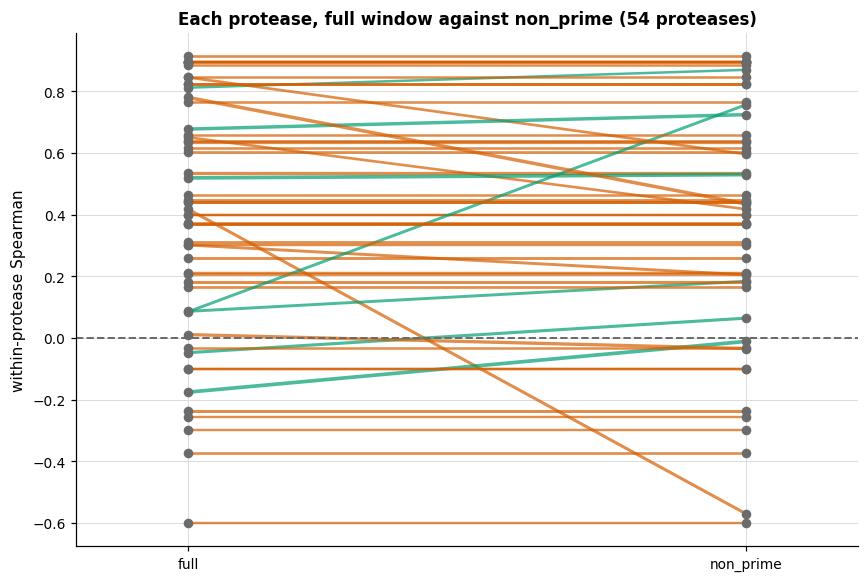

In [8]:
best_variant = (
    main[(main["dataset"] == "extended") & (main["variant"] != "full")]
    .sort_values("pooled_rho", ascending=False)["variant"].iloc[0]
)
fig, ax = plt.subplots(figsize=(8.0, 5.4))
reference = per_protease[(per_protease["dataset"] == "extended") & (per_protease["variant"] == "full")].set_index("merops_code")
candidate = per_protease[(per_protease["dataset"] == "extended") & (per_protease["variant"] == best_variant)].set_index("merops_code")
shared = reference.index.intersection(candidate.index)
for code in shared:
    improved = candidate.loc[code, "rho"] > reference.loc[code, "rho"]
    ax.plot([0, 1], [reference.loc[code, "rho"], candidate.loc[code, "rho"]],
            color=common.CATEGORICAL_COLORS[2] if improved else common.CATEGORICAL_COLORS[1],
            linewidth=1.0 + np.log1p(reference.loc[code, "substrates"]) / 3, alpha=0.7, zorder=2)
ax.scatter(np.zeros(len(shared)), reference.loc[shared, "rho"], s=28, color=common.NEUTRAL, zorder=3)
ax.scatter(np.ones(len(shared)), candidate.loc[shared, "rho"], s=28, color=common.NEUTRAL, zorder=3)
ax.axhline(0.0, color=common.NEUTRAL, linestyle="--", linewidth=1.3)
ax.set_xticks([0, 1])
ax.set_xticklabels(["full", best_variant])
ax.set_xlim(-0.2, 1.2)
ax.set_ylabel("within-protease Spearman")
ax.set_title(f"Each protease, full window against {best_variant} ({len(shared)} proteases)")
fig.tight_layout()
plt.show()

## Is the change a change in the score or in the bond?

For a substrate whose bond is latent, restricting the window changes two things at
once: the score of any given bond, and which bond wins. The control run keeps the
bond the full window chose and rescores only, so the two effects can be separated.

In [9]:
separation = (
    summary.pivot_table(index=["dataset", "variant"], columns="bond_refitted", values="pooled_rho")
    .rename(columns={True: "bond_refitted", False: "bond_fixed"})
    .reset_index()
)
separation["difference"] = separation["bond_refitted"] - separation["bond_fixed"]
print(separation.round(4).to_string(index=False))

 dataset   variant  bond_fixed  bond_refitted  difference
baseline    P1_P1p      0.1553         0.1991      0.0438
baseline   P1_only      0.1098         0.1919      0.0821
baseline     P2_P1      0.2481         0.2522      0.0041
baseline     P3_P1      0.3557         0.3574      0.0017
baseline      core      0.2512         0.2421     -0.0091
baseline      full      0.3045         0.3045      0.0000
baseline non_prime      0.3717         0.3732      0.0015
baseline     prime     -0.0466         0.1534      0.2000
extended    P1_P1p      0.2882         0.3158      0.0276
extended   P1_only      0.1869         0.2168      0.0300
extended     P2_P1      0.2497         0.2624      0.0128
extended     P3_P1      0.3178         0.3262      0.0084
extended      core      0.3241         0.3234     -0.0008
extended      full      0.3728         0.3728      0.0000
extended non_prime      0.3486         0.3482     -0.0005
extended     prime      0.1459         0.2892      0.1432


In [10]:
common.save_result(main, "2_08_window_variants.csv")
common.save_result(per_protease, "2_08_variant_per_protease.csv")
common.save_result(paired, "2_08_variant_paired.csv")
common.save_result(separation, "2_08_variant_bond_separation.csv")

PosixPath('/home/max/repositories/pep-compass/assets/experiments/analysis/09_26/20_serum_proteolysis_calibration_max/results/2_08_variant_bond_separation.csv')

## Findings and decisions

**The prime side is weaker than the non-prime side, and the evidence for that is
consistent across both datasets.** The `prime` variant is the worst of all eight on
the baseline set ($\rho = 0.153$ against $0.305$ for the full window) and among the
worst on the extended set ($0.289$ against $0.373$). Since `prime` and `non_prime`
use the same four subsites, the gap between them is not a complexity effect: it is a
statement about which side of the scissile bond carries information that survives
into a measured rate. That is what the reporter-substrate construction predicts —
the experimenter designs the non-prime side around the known preference and the
prime side around the quencher chemistry.

`prime` also supports far fewer proteases (8 on the baseline set, 15 on the
extended) because many substrates occupy no prime-side subsites at all, which is
itself part of the answer.

**Dropping the prime side nevertheless does not improve the model, and the two
datasets are what establish that.**

| Variant | subsites | baseline $\rho$ | extended $\rho$ |
| --- | --- | --- | --- |
| `non_prime` | 4 | **0.373** | 0.348 |
| `P3_P1` | 3 | 0.357 | 0.326 |
| `full` | 8 | 0.305 | **0.373** |
| `core` | 4 | 0.242 | 0.323 |
| `P2_P1` | 2 | 0.252 | 0.262 |
| `prime` | 4 | 0.153 | 0.289 |
| `P1_only` | 1 | 0.192 | 0.217 |

On the baseline set `non_prime` beats the full window by $+0.069$, which read alone
would be a clear recommendation to drop four subsites. On the extended set the
ordering inverts and the full window wins by $+0.025$. Running the comparison on one
dataset would have produced a confident and wrong conclusion.

**The paired test explains the inversion.** On the baseline set `non_prime` is
better than the full window on only **5 of 16** proteases, and on the extended set on
**7 of 54**. In both cases the majority of enzymes are worse off; the pooled gain on
the baseline set is produced by a few well-populated proteases and the weighting
that favours them. The direction is not general, so the pooled number was the
misleading statistic and the per-protease share is the informative one.

**Decision: the full $P_4 \ldots P_4'$ window stays.** It wins on the dataset with
fifty-eight proteases, it never loses badly on the other, and no restricted variant
improves a majority of individual enzymes. The prime side is weak but it is not
noise, and removing it costs more than it saves once enough enzymes are in the
comparison.

**What would change this.** The result is about substrates that are overwhelmingly
synthetic reporters. A dataset of natural substrates, where the prime side is not
designed, could reverse it, and `0_07` names the kind of source that would supply
one.